In [1]:
# ============================================================
# Notebook 09: Final Unseen Test Evaluation
# ============================================================
#
# PURPOSE:
#   Evaluate the three finalised MIL architectures exactly once
#   on the completely held-out test set.
#
# IMPORTANT:
#   - No training occurs here.
#   - No hyperparameter tuning occurs here.
#   - No threshold optimisation occurs here.
#   - No model selection occurs using test labels.
#   - Test labels are used ONLY for final performance metrics.
#
# Models:
#   1. EfficientNet-B0
#   2. ConvNeXt-Nano
#   3. Swin-T
# ============================================================

In [2]:
import sys
sys.path.append(
    '/kaggle/input/datasets/mfjmrizvi/cbis-ddsm-project-config'
)

import json
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from sklearn.metrics import (
    roc_auc_score,roc_curve,f1_score,confusion_matrix,accuracy_score
)

from abmil_common import (
    PatchClassifier,BagClassifier, CachedBagDataset, collate_cached,
    extract_features,compute_all_metrics,build_backbone,
    get_normalisation_tensors
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

_mean_gpu, _std_gpu = get_normalisation_tensors(DEVICE)

print("=" * 65)
print("NB09 — FINAL UNSEEN TEST EVALUATION")
print("=" * 65)
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
print(f"Device  : {DEVICE}")

NB09 — FINAL UNSEEN TEST EVALUATION
PyTorch : 2.10.0+cu128
CUDA    : True
Device  : cuda


In [3]:
NB02 = Path("/kaggle/input/notebooks/mfjmrizvi/02-mil-patch-extraction")
NB03 = Path("/kaggle/input/notebooks/mfjmrizvi/03-efficientnet-b0")
NB05 = Path("/kaggle/input/notebooks/mfjmrizvi/05-swint")
NB07 = Path("/kaggle/input/notebooks/mfjmrizvi/07-optuna")
OUT  = Path("/kaggle/working")

# Test data
X_TEST_PATH       = NB02 / "X_test_patches.npy"
Y_TEST_PATH       = NB02 / "y_test_labels.npy"
BAG_IDS_TEST_PATH = NB02 / "bag_ids_test.npy"

# Final model checkpoints 
# all three use NB07 Optuna-tuned Stage 2 heads on top of their respective Stage 1 backbones, so that
# "same procedure except backbone" (Section 3.4/3.5.4) holds:
#   EfficientNet-B0 : Stage1 NB03 baseline | Stage2 NB07 Optuna (Part B)
#   ConvNeXt-Nano   : Stage1 NB07 v2 retrain (Part A) cause baseline was broken | Stage2 NB07 Optuna (Part C)
#   Swin-T          : Stage1 NB05 baseline | Stage2 NB07 Optuna (Part B)
EFFNET_S1 = NB03 / "efficientnet_b0_stage1.pth"
EFFNET_S2 = NB07 / "effnet_b0_optuna_stage2.pth"

CONVNEXT_S1 = NB07 / "convnext_nano_v2_stage1.pth"
CONVNEXT_S2 = NB07 / "convnext_nano_optuna_stage2.pth"

SWINT_S1 = NB05 / "swin_t_stage1.pth"
SWINT_S2 = NB07 / "swin_t_optuna_stage2.pth"

print("Checkpoint paths configured")

Checkpoint paths configured


In [4]:
#Final architecture parameters (fixed before touching test set)
# Pulled directly from NB07's printed Optuna best_params per model.
EFFNET_FEAT_DIM = 1280
EFFNET_ATTN_DIM = 256
EFFNET_DROPOUT  = 0.14607232426760908

CONVNEXT_FEAT_DIM = 640
CONVNEXT_ATTN_DIM = 128
CONVNEXT_DROPOUT  = 0.11177411355757738

SWINT_FEAT_DIM = 768
SWINT_ATTN_DIM = 256
SWINT_DROPOUT  = 0.34411475597509966

print("EfficientNet-B0 :", EFFNET_FEAT_DIM, EFFNET_ATTN_DIM, EFFNET_DROPOUT)
print("ConvNeXt-Nano   :", CONVNEXT_FEAT_DIM, CONVNEXT_ATTN_DIM, CONVNEXT_DROPOUT)
print("Swin-T          :", SWINT_FEAT_DIM, SWINT_ATTN_DIM, SWINT_DROPOUT)

EfficientNet-B0 : 1280 256 0.14607232426760908
ConvNeXt-Nano   : 640 128 0.11177411355757738
Swin-T          : 768 256 0.34411475597509966


In [5]:
#Final thresholds (from validation data only, not test)
# 4-decimal fallbacks match NB07's printed console output.
EFFNET_THRESHOLD   = 0.3453
CONVNEXT_THRESHOLD = 0.2808
SWINT_THRESHOLD    = 0.2749

# Prefer full-precision thresholds from NB07's saved JSONs if present.
_threshold_sources = {
    "EFFNET_THRESHOLD":   (NB07 / "effnet_b0_optuna_results.json", EFFNET_THRESHOLD),
    "CONVNEXT_THRESHOLD": (NB07 / "convnext_nano_optuna_results.json", CONVNEXT_THRESHOLD),
    "SWINT_THRESHOLD":    (NB07 / "swin_t_optuna_results.json", SWINT_THRESHOLD),
}

for _name, (_path, _fallback) in _threshold_sources.items():
    if _path.exists():
        with open(_path) as _f:
            _val = json.load(_f).get("optimal_threshold", _fallback)
        globals()[_name] = float(_val)
        print(f"{_name}: loaded full-precision value {_val:.6f} from {_path.name}")
    else:
        print(f"{_name}: {_path.name} not found — using 4-decimal fallback {_fallback}")

RESULTS_JSON = OUT / "nb09_final_unseen_test_results.json"

EFFNET_THRESHOLD: loaded full-precision value 0.345346 from effnet_b0_optuna_results.json
CONVNEXT_THRESHOLD: loaded full-precision value 0.280847 from convnext_nano_optuna_results.json
SWINT_THRESHOLD: loaded full-precision value 0.274858 from swin_t_optuna_results.json


In [6]:
#Checkpoint verification
checkpoint_paths = {
    "EfficientNet-B0 Stage 1": EFFNET_S1,
    "EfficientNet-B0 Stage 2": EFFNET_S2,
    "ConvNeXt-Nano Stage 1":   CONVNEXT_S1,
    "ConvNeXt-Nano Stage 2":   CONVNEXT_S2,
    "Swin-T Stage 1":          SWINT_S1,
    "Swin-T Stage 2":          SWINT_S2,
}

print("Checkpoint verification:")
for name, path in checkpoint_paths.items():
    print(f"{'✓' if path.exists() else '✗ MISSING'}  {name}: {path}")

Checkpoint verification:
✓  EfficientNet-B0 Stage 1: /kaggle/input/notebooks/mfjmrizvi/03-efficientnet-b0/efficientnet_b0_stage1.pth
✓  EfficientNet-B0 Stage 2: /kaggle/input/notebooks/mfjmrizvi/07-optuna/effnet_b0_optuna_stage2.pth
✓  ConvNeXt-Nano Stage 1: /kaggle/input/notebooks/mfjmrizvi/07-optuna/convnext_nano_v2_stage1.pth
✓  ConvNeXt-Nano Stage 2: /kaggle/input/notebooks/mfjmrizvi/07-optuna/convnext_nano_optuna_stage2.pth
✓  Swin-T Stage 1: /kaggle/input/notebooks/mfjmrizvi/05-swint/swin_t_stage1.pth
✓  Swin-T Stage 2: /kaggle/input/notebooks/mfjmrizvi/07-optuna/swin_t_optuna_stage2.pth


In [7]:
#Load held-out test data
print("Loading held-out test set...")

X_test = np.load(X_TEST_PATH)
y_test = np.load(Y_TEST_PATH)
bag_ids_test = np.load(BAG_IDS_TEST_PATH)

test_bag_ids = np.unique(bag_ids_test)

print(f"X_test shape      : {X_test.shape}")
print(f"y_test shape      : {y_test.shape}")
print(f"Test bags/patients: {len(test_bag_ids)}")

print("\nTest label distribution:")
print(f"  Benign     : {np.sum(y_test == 0)} patches")
print(f"  Malignant  : {np.sum(y_test == 1)} patches")

print("\nIMPORTANT: this test set is used only for final inference and evaluation.")

Loading held-out test set...
X_test shape      : (17502, 224, 224, 1)
y_test shape      : (17502,)
Test bags/patients: 365

Test label distribution:
  Benign     : 10547 patches
  Malignant  : 6955 patches

IMPORTANT: this test set is used only for final inference and evaluation.


In [8]:
#Test inference function
def predict_test_bags(
    model_name,
    feat_dim,
    attn_dim,
    dropout,
    s1_path,
    s2_path,
    X_test,
    y_test,
    bag_ids_test
):
    """
    Run final inference on the completely held-out test set.
    No training or parameter fitting occurs here.
    """
    print(f"\n{'=' * 60}")
    print(f"Evaluating {model_name}")
    print(f"{'=' * 60}")

    # Stage 1: load trained patch classifier
    backbone = build_backbone(model_name, pretrained=True).to(DEVICE)
    patch_model = PatchClassifier(backbone, feat_dim).to(DEVICE)
    patch_model.load_state_dict(torch.load(s1_path, map_location=DEVICE))
    patch_model.eval()

    # Freeze backbone for feature extraction
    feature_extractor = patch_model.backbone
    feature_extractor.eval()
    for p in feature_extractor.parameters():
        p.requires_grad_(False)

    # Extract features from TEST patches
    print("Extracting test features...")
    test_features = extract_features(X_test, feature_extractor, _mean_gpu, _std_gpu, DEVICE)
    print(f"Feature shape: {test_features.shape}")

    # Stage 2: load trained ABMIL classifier
    bag_model = BagClassifier(feat_dim, attn_dim, dropout).to(DEVICE)
    bag_model.load_state_dict(torch.load(s2_path, map_location=DEVICE))
    bag_model.eval()

    # Bag-level inference
    test_dataset = CachedBagDataset(test_features, y_test, bag_ids_test, test_bag_ids)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_cached)

    probabilities, labels, returned_bag_ids = [], [], []
    with torch.no_grad():
        for bag_idx, (h_list, bag_label) in enumerate(test_loader):
            h = h_list[0].to(DEVICE)
            logit, _ = bag_model(h)
            probabilities.append(torch.sigmoid(logit).item())
            labels.append(bag_label[0].item())
            returned_bag_ids.append(test_bag_ids[bag_idx])

    probabilities = np.asarray(probabilities, dtype=np.float64)
    labels = np.asarray(labels, dtype=np.int64)
    returned_bag_ids = np.asarray(returned_bag_ids)

    print(f"Test bags evaluated: {len(probabilities)}")
    return probabilities, labels, returned_bag_ids

print("predict_test_bags() defined")

predict_test_bags() defined


In [9]:
#Run final inference: EfficientNet-B0
print("The test labels are NOT used to select, tune, or modify any model.\n")

eff_test, eff_true, eff_bags = predict_test_bags(
    model_name="efficientnet_b0",
    feat_dim=EFFNET_FEAT_DIM,
    attn_dim=EFFNET_ATTN_DIM,
    dropout=EFFNET_DROPOUT,
    s1_path=EFFNET_S1,
    s2_path=EFFNET_S2,
    X_test=X_test,
    y_test=y_test,
    bag_ids_test=bag_ids_test
)

The test labels are NOT used to select, tune, or modify any model.


Evaluating efficientnet_b0


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Extracting test features...
Feature shape: (17502, 1280)
Test bags evaluated: 365


In [10]:
#Run final inference: ConvNeXt-Nano
cnx_test, cnx_true, cnx_bags = predict_test_bags(
    model_name="convnext_nano",
    feat_dim=CONVNEXT_FEAT_DIM,
    attn_dim=CONVNEXT_ATTN_DIM,
    dropout=CONVNEXT_DROPOUT,
    s1_path=CONVNEXT_S1,
    s2_path=CONVNEXT_S2,
    X_test=X_test,
    y_test=y_test,
    bag_ids_test=bag_ids_test
)


Evaluating convnext_nano


model.safetensors:   0%|          | 0.00/62.4M [00:00<?, ?B/s]

Extracting test features...
Feature shape: (17502, 640)
Test bags evaluated: 365


In [11]:
#Run final inference: Swin-T
swin_test, swin_true, swin_bags = predict_test_bags(
    model_name="swin_tiny_patch4_window7_224",
    feat_dim=SWINT_FEAT_DIM,
    attn_dim=SWINT_ATTN_DIM,
    dropout=SWINT_DROPOUT,
    s1_path=SWINT_S1,
    s2_path=SWINT_S2,
    X_test=X_test,
    y_test=y_test,
    bag_ids_test=bag_ids_test
)


Evaluating swin_tiny_patch4_window7_224


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Extracting test features...
Feature shape: (17502, 768)
Test bags evaluated: 365


In [12]:
#Patient/bag alignment audit
print("=" * 65)
print("ALIGNMENT AUDIT")
print("=" * 65)

assert np.array_equal(eff_true, cnx_true), "EfficientNet and ConvNeXt labels differ!"
assert np.array_equal(eff_true, swin_true), "EfficientNet and Swin labels differ!"
assert np.array_equal(eff_bags, cnx_bags), "EfficientNet and ConvNeXt bag order differs!"
assert np.array_equal(eff_bags, swin_bags), "EfficientNet and Swin bag order differs!"

print("✓ Identical test bag order")
print("✓ Identical test labels")
print("✓ Same patient-level test cohort")
print(f"✓ {len(eff_bags)} test bags")

ALIGNMENT AUDIT
✓ Identical test bag order
✓ Identical test labels
✓ Same patient-level test cohort
✓ 365 test bags


In [13]:
# Final test metrics table
models = {
    "EfficientNet-B0": (eff_true, eff_test, EFFNET_THRESHOLD),
    "ConvNeXt-Nano":   (cnx_true, cnx_test, CONVNEXT_THRESHOLD),
    "Swin-T":          (swin_true, swin_test, SWINT_THRESHOLD)
}

final_metrics = {}

print("=" * 80)
print("FINAL UNSEEN TEST PERFORMANCE")
print("=" * 80)
print(f"{'Model':<20}{'AUC':<10}{'F1':<10}{'Sens':<10}{'Spec':<10}{'FPR':<10}{'ECE':<10}")
print("-" * 80)

for name, (true, probs, threshold) in models.items():
    metrics = compute_all_metrics(true, probs, threshold, name)
    final_metrics[name] = metrics
    print(
        f"{name:<20}"
        f"{metrics['auc']:<10.4f}"
        f"{metrics['f1']:<10.4f}"
        f"{metrics['sensitivity']:<10.4f}"
        f"{metrics['specificity']:<10.4f}"
        f"{metrics['fpr']:<10.4f}"
        f"{metrics['ece']:<10.4f}"
    )

FINAL UNSEEN TEST PERFORMANCE
Model               AUC       F1        Sens      Spec      FPR       ECE       
--------------------------------------------------------------------------------
── EfficientNet-B0 ──
  threshold      : 0.3453
  auc            : 0.7377
  f1             : 0.6143
  sensitivity    : 0.8897
  specificity    : 0.3364
  fpr            : 0.6636
  mcc            : 0.2566
  ece            : 0.0771
  confusion      : TN=74 FP=146 FN=16 TP=129
EfficientNet-B0     0.7377    0.6143    0.8897    0.3364    0.6636    0.0771    
── ConvNeXt-Nano ──
  threshold      : 0.2808
  auc            : 0.7441
  f1             : 0.6028
  sensitivity    : 0.8897
  specificity    : 0.3000
  fpr            : 0.7000
  mcc            : 0.2224
  ece            : 0.1122
  confusion      : TN=66 FP=154 FN=16 TP=129
ConvNeXt-Nano       0.7441    0.6028    0.8897    0.3000    0.7000    0.1122    
── Swin-T ──
  threshold      : 0.2749
  auc            : 0.7478
  f1             : 0.6127
  sensi

In [14]:
#High-precision test AUC
print("=" * 65)
print("HIGH-PRECISION TEST AUC")
print("=" * 65)

for name, (true, probs, _) in models.items():
    auc = roc_auc_score(true, probs)
    print(f"{name:<20} AUC = {auc:.10f}")

HIGH-PRECISION TEST AUC
EfficientNet-B0      AUC = 0.7377429467
ConvNeXt-Nano        AUC = 0.7440752351
Swin-T               AUC = 0.7477742947


In [15]:
#Final model ranking
print("=" * 65)
print("FINAL MODEL RANKING : HELD-OUT TEST SET")
print("=" * 65)

ranked = sorted(
    final_metrics.keys(),
    key=lambda name: final_metrics[name]["auc"],
    reverse=True
)

for rank, name in enumerate(ranked, 1):
    m = final_metrics[name]
    print(
        f"{rank}. {name:<20} "
        f"AUC={m['auc']:.4f} | "
        f"F1={m['f1']:.4f} | "
        f"Sens={m['sensitivity']:.4f} | "
        f"Spec={m['specificity']:.4f} | "
        f"ECE={m['ece']:.4f}"
    )

FINAL MODEL RANKING : HELD-OUT TEST SET
1. Swin-T               AUC=0.7478 | F1=0.6127 | Sens=0.8345 | Spec=0.4136 | ECE=0.0967
2. ConvNeXt-Nano        AUC=0.7441 | F1=0.6028 | Sens=0.8897 | Spec=0.3000 | ECE=0.1122
3. EfficientNet-B0      AUC=0.7377 | F1=0.6143 | Sens=0.8897 | Spec=0.3364 | ECE=0.0771


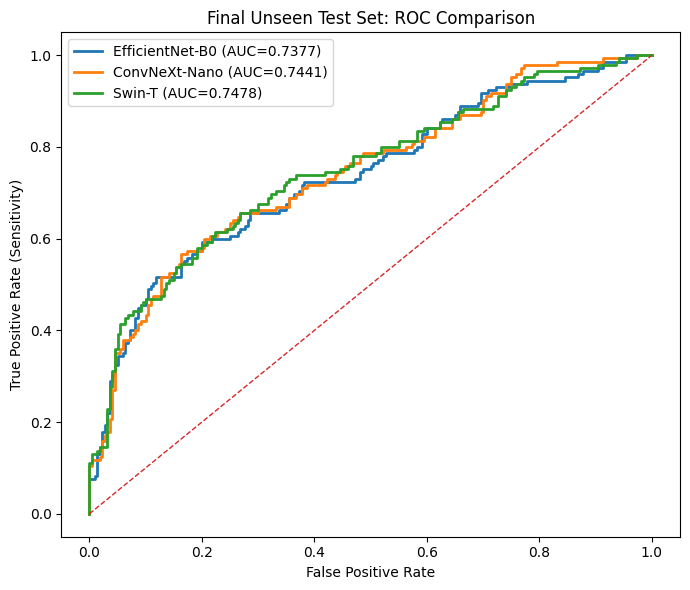

In [16]:
#Final ROC curves
plt.figure(figsize=(7, 6))

for name, (true, probs, _) in models.items():
    fpr, tpr, _ = roc_curve(true, probs)
    auc = roc_auc_score(true, probs)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("Final Unseen Test Set: ROC Comparison")
plt.legend()
plt.tight_layout()

plt.savefig(OUT / "nb09_final_unseen_test_roc.png", dpi=150, bbox_inches="tight")
plt.show()

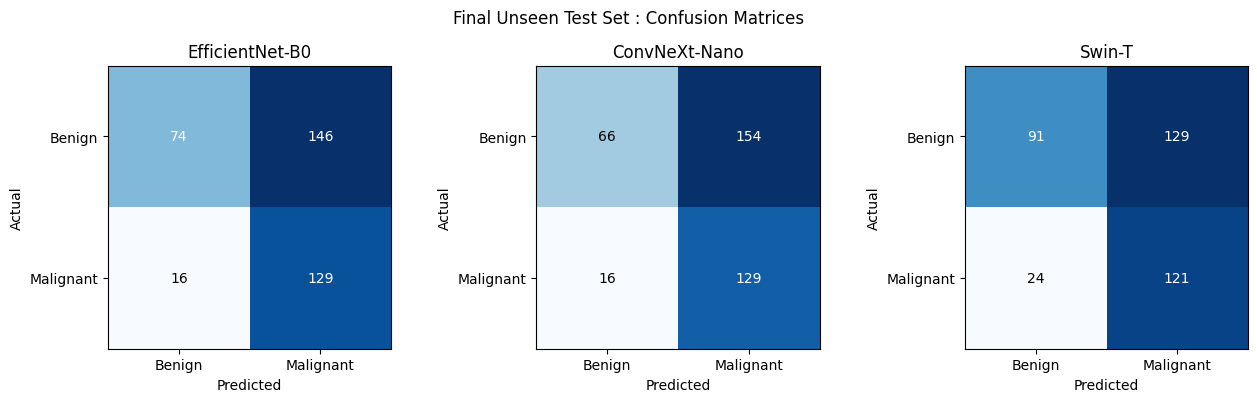

In [17]:
#Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (name, (true, probs, threshold)) in zip(axes, models.items()):
    predicted = (probs >= threshold).astype(int)
    cm = confusion_matrix(true, predicted)

    ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Benign", "Malignant"])
    ax.set_yticklabels(["Benign", "Malignant"])
    threshold_value = cm.max() / 2

    for i in range(2):
        for j in range(2):
            text_color = "white" if cm[i, j] > threshold_value else "black"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=text_color)

plt.suptitle("Final Unseen Test Set : Confusion Matrices")
plt.tight_layout()

plt.savefig(OUT / "nb09_final_unseen_test_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
#DeLong test helper functions
def _compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)

    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j

    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2


def _fast_delong(preds_sorted_transposed, m):
    n = preds_sorted_transposed.shape[1] - m
    k = preds_sorted_transposed.shape[0]

    pos = preds_sorted_transposed[:, :m]
    neg = preds_sorted_transposed[:, m:]

    tx = np.empty([k, m])
    ty = np.empty([k, n])
    tz = np.empty([k, m + n])

    for r in range(k):
        tx[r, :] = _compute_midrank(pos[r, :])
        ty[r, :] = _compute_midrank(neg[r, :])
        tz[r, :] = _compute_midrank(preds_sorted_transposed[r, :])

    aucs = (
        tz[:, :m].sum(axis=1) / m / n
        - (m + 1.0) / (2.0 * n)
    )

    v01 = (tz[:, :m] - tx) / n
    v10 = (1.0 - (tz[:, m:] - ty) / m)

    sx = np.cov(v01)
    sy = np.cov(v10)
    delongcov = sx / m + sy / n

    return aucs, delongcov


def delong_roc_test(y_true, probs_a, probs_b):
    order = np.argsort(-y_true, kind="stable")
    y_sorted = y_true[order]
    m = int(np.sum(y_sorted == 1))

    preds = np.vstack([probs_a[order], probs_b[order]])
    aucs, cov = _fast_delong(preds, m)

    auc_diff = aucs[0] - aucs[1]
    var = cov[0, 0] + cov[1, 1] - 2 * cov[0, 1]

    if var <= 0:
        return float(aucs[0]), float(aucs[1]), np.nan, np.nan

    z = auc_diff / np.sqrt(var)

    from scipy.stats import norm
    p = 2 * (1 - norm.cdf(abs(z)))

    return float(aucs[0]), float(aucs[1]), float(z), float(p)

print("DeLong test functions defined")

DeLong test functions defined


In [19]:
#Pairwise DeLong comparisons
pairs = [
    ("EfficientNet-B0", "ConvNeXt-Nano"),
    ("EfficientNet-B0", "Swin-T"),
    ("ConvNeXt-Nano", "Swin-T"),
]

delong_results = {}

print("=" * 80)
print("PAIRWISE DeLong TESTS : FINAL TEST SET")
print("=" * 80)
print(f"{'Comparison':<38}{'AUC A':<10}{'AUC B':<10}{'p-value':<12}{'Significant'}")
print("-" * 80)

for name_a, name_b in pairs:
    true_a, probs_a, _ = models[name_a]
    true_b, probs_b, _ = models[name_b]
    assert np.array_equal(true_a, true_b)

    auc_a, auc_b, z, p = delong_roc_test(true_a, probs_a, probs_b)
    significant = "Yes" if not np.isnan(p) and p < 0.05 else "No"
    key = f"{name_a}_vs_{name_b}"

    delong_results[key] = {
        "auc_a": auc_a, "auc_b": auc_b,
        "z": z, "p_value": p,
        "significant_at_0.05": significant
    }

    print(f"{name_a + ' vs ' + name_b:<38}{auc_a:<10.4f}{auc_b:<10.4f}{p:<12.4f}{significant}")

PAIRWISE DeLong TESTS : FINAL TEST SET
Comparison                            AUC A     AUC B     p-value     Significant
--------------------------------------------------------------------------------
EfficientNet-B0 vs ConvNeXt-Nano      0.7377    0.7441    0.7255      No
EfficientNet-B0 vs Swin-T             0.7377    0.7478    0.5872      No
ConvNeXt-Nano vs Swin-T               0.7441    0.7478    0.8050      No


In [20]:
#Save final results JSON
final_results = {
    "evaluation": {
        "purpose": "Final evaluation of finalized models on completely held-out test data.",
        "test_used_for_training": False,
        "test_used_for_hyperparameter_tuning": False,
        "test_used_for_threshold_selection": False,
        "test_used_for_model_selection": False,
        "test_evaluation_stage": "NB09",
        "test_bags": int(len(test_bag_ids)),
        "test_patches": int(len(X_test)),
    },
    "models": {
        "EfficientNet-B0": {
            "stage1_checkpoint": str(EFFNET_S1),
            "stage2_checkpoint": str(EFFNET_S2),
            "feature_dim": EFFNET_FEAT_DIM,
            "attention_dim": EFFNET_ATTN_DIM,
            "dropout": EFFNET_DROPOUT,
            "threshold": EFFNET_THRESHOLD,
            "metrics": final_metrics["EfficientNet-B0"]
        },
        "ConvNeXt-Nano": {
            "stage1_checkpoint": str(CONVNEXT_S1),
            "stage2_checkpoint": str(CONVNEXT_S2),
            "feature_dim": CONVNEXT_FEAT_DIM,
            "attention_dim": CONVNEXT_ATTN_DIM,
            "dropout": CONVNEXT_DROPOUT,
            "threshold": CONVNEXT_THRESHOLD,
            "metrics": final_metrics["ConvNeXt-Nano"]
        },
        "Swin-T": {
            "stage1_checkpoint": str(SWINT_S1),
            "stage2_checkpoint": str(SWINT_S2),
            "feature_dim": SWINT_FEAT_DIM,
            "attention_dim": SWINT_ATTN_DIM,
            "dropout": SWINT_DROPOUT,
            "threshold": SWINT_THRESHOLD,
            "metrics": final_metrics["Swin-T"]
        }
    },
    "delong_pairwise": delong_results,
    "ranking_by_auc": ranked
}

with open(RESULTS_JSON, "w") as f:
    json.dump(final_results, f, indent=2)

print(f"Saved final results to:\n{RESULTS_JSON}")

Saved final results to:
/kaggle/working/nb09_final_unseen_test_results.json
